In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Membaca Gambar

In [2]:
image_path = 'Nama.jpeg'
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [3]:
R, G, B = cv2.split(img_rgb)
R_int = R.astype(np.int32)
G_int = G.astype(np.int32)
B_int = B.astype(np.int32)
margin = 25

In [4]:
mask_blue = (B_int > R_int + margin) & (B_int > G_int + margin)
mask_red = (R_int > G_int + margin) & (R_int > B_int + margin)
mask_green = (G_int > R_int + margin) & (G_int > B_int + margin)

citra_kontras = np.ones_like(img_rgb) * 255
citra_kontras[mask_blue] = img_rgb[mask_blue]
citra_kontras[mask_red] = img_rgb[mask_red]
citra_kontras[mask_green] = img_rgb[mask_green]

B_ideal = np.ones_like(B) * 255
R_ideal = np.ones_like(R) * 255
G_ideal = np.ones_like(G) * 255

B_ideal[mask_blue] = 235
B_ideal[mask_red] = 40
B_ideal[mask_green] = 40

R_ideal[mask_red] = 235
R_ideal[mask_blue] = 40 
R_ideal[mask_green] = 40

G_ideal[mask_green] = 235
G_ideal[mask_blue] = 40
G_ideal[mask_red] = 40

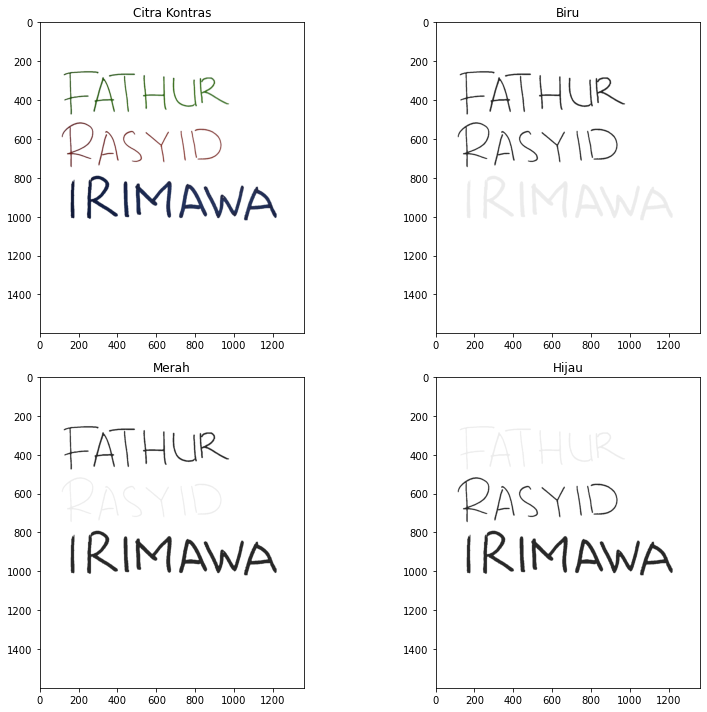

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].imshow(citra_kontras)
axs[0, 0].set_title('Citra Kontras')
axs[0, 0].axis('on') 

axs[0, 1].imshow(B_ideal, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Biru')

axs[1, 0].imshow(R_ideal, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title('Merah')

axs[1, 1].imshow(G_ideal, cmap='gray', vmin=0, vmax=255)
axs[1, 1].set_title('Hijau')

plt.tight_layout()
plt.show()

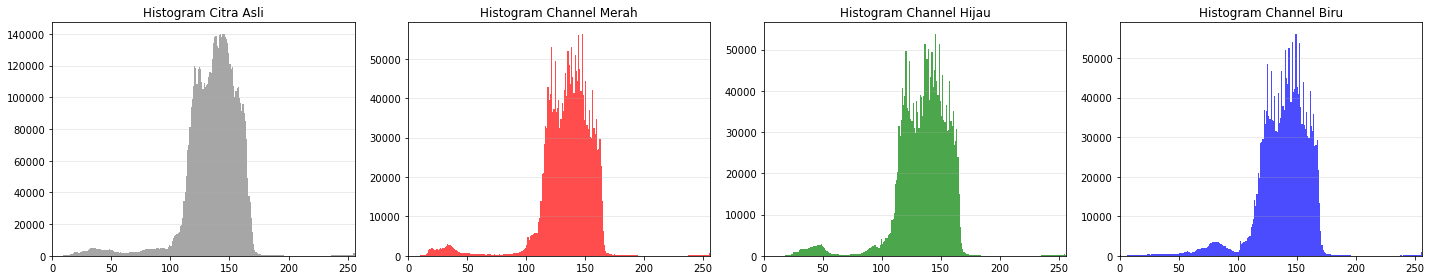

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

axs[0].hist(img_rgb.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axs[0].set_title('Histogram Citra Asli')
axs[0].set_xlim([0, 256])
axs[0].grid(axis='y', alpha=0.3)

axs[1].hist(R.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
axs[1].set_title('Histogram Channel Merah')
axs[1].set_xlim([0, 256])
axs[1].grid(axis='y', alpha=0.3)

axs[2].hist(G.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axs[2].set_title('Histogram Channel Hijau')
axs[2].set_xlim([0, 256])
axs[2].grid(axis='y', alpha=0.3)

axs[3].hist(B.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axs[3].set_title('Histogram Channel Biru')
axs[3].set_xlim([0, 256])
axs[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
img_none = np.zeros_like(R)

img_blue_only = np.zeros_like(R)
img_blue_only[mask_blue] = 255

img_red_blue = np.zeros_like(R)
img_red_blue[mask_red | mask_blue] = 255

img_all = np.zeros_like(R)
img_all[mask_red | mask_green | mask_blue] = 255

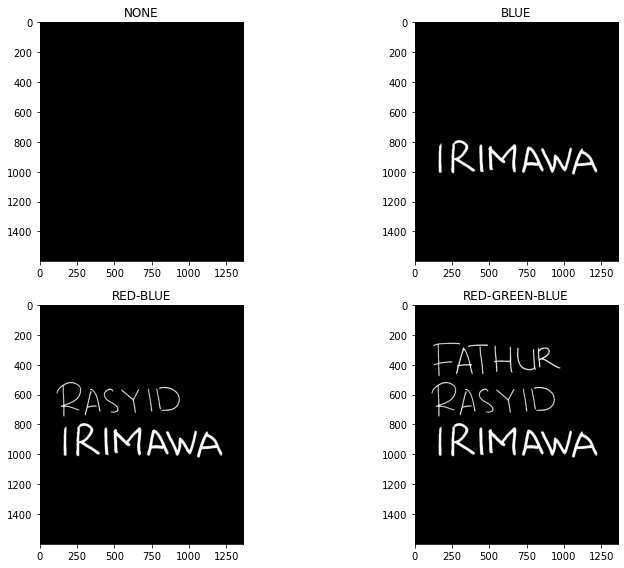

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img_none, cmap='gray')
axs[0, 0].set_title('NONE')

axs[0, 1].imshow(img_blue_only, cmap='gray')
axs[0, 1].set_title('BLUE')

axs[1, 0].imshow(img_red_blue, cmap='gray')
axs[1, 0].set_title('RED-BLUE')

axs[1, 1].imshow(img_all, cmap='gray')
axs[1, 1].set_title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()